
# Projeto FIAP — Fase 5  
**Aluno:** Gabriel Peter  
**RM:** PREENCHER  
**Arquivo:** `GabrielPeter_rm567586_pbl_fase4.ipynb`

## Objetivo
Este notebook entrega os dois pontos obrigatórios da fase:

1. **Machine Learning**: análise exploratória, clusterização, análise de outliers e construção de **cinco modelos de regressão** para prever o rendimento (`Yield`).
2. **Computação em Nuvem**: apoio ao README com a justificativa de hospedagem em AWS.



In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold, cross_validate
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

df = pd.read_csv('../data/crop_yield.csv')
df.head()


,Fert,Water,Yield
0,A,High,27.4
1,A,High,33.6
2,A,High,29.8
3,A,High,35.2
4,A,High,33.0



## 1. Entendimento da base
O dataset é pequeno e tabular, com uma variável alvo numérica (`Yield`) e duas variáveis categóricas (`Fert` e `Water`).

A primeira leitura já mostra uma vantagem para o projeto: por ser um conjunto compacto, é possível testar rapidamente diferentes algoritmos e comparar comportamento com baixo custo computacional.


In [2]:

print('Shape:', df.shape)
print('\nTipos:')
print(df.dtypes)
print('\nValores ausentes:')
print(df.isna().sum())
print('\nEstatísticas do Yield:')
display(df['Yield'].describe().to_frame().T)


Shape: (20, 3)

Tipos:
Fert      object
Water     object
Yield    float64
dtype: object

Valores ausentes:
Fert     0
Water    0
Yield    0
dtype: int64

Estatísticas do Yield:


,count,mean,std,min,25%,50%,75%,max
Yield,20.0,29.04,4.230516,19.4,26.4,29.6,32.4,35.2


In [3]:

summary_by_group = (
    df.groupby(['Fert', 'Water'])['Yield']
      .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
      .reset_index()
)
summary_by_group


,Fert,Water,count,mean,median,std,min,max
0,A,High,5,31.80,33.0,3.146427,27.4,35.2
1,A,Low,5,30.00,32.0,3.512834,26.0,33.4
2,B,High,5,29.84,30.2,3.374611,26.4,34.8
3,B,Low,5,24.52,23.8,3.791042,19.4,29.4



## 2. Análise exploratória (EDA)
Como as features são categóricas, a análise exploratória foca em:

- distribuição do `Yield`;
- comparação do rendimento por nível de fertilizante;
- comparação do rendimento por nível de irrigação;
- combinação entre `Fert` e `Water`.


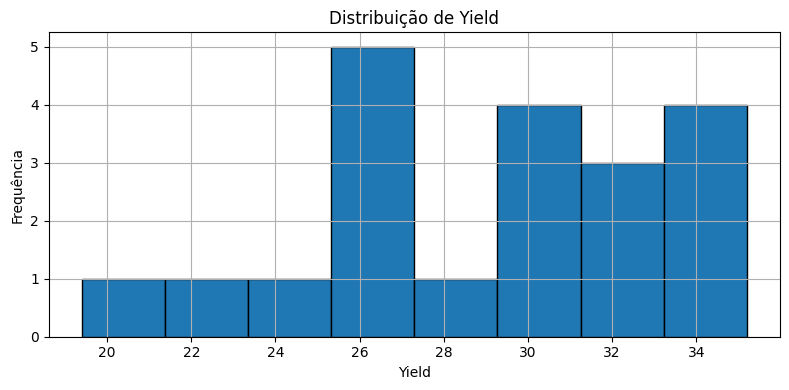

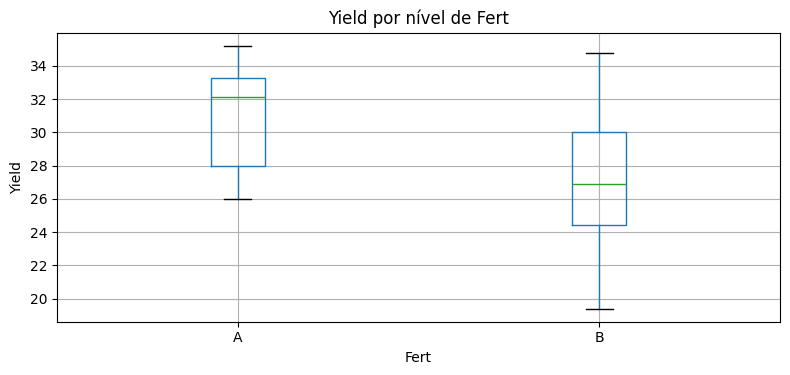

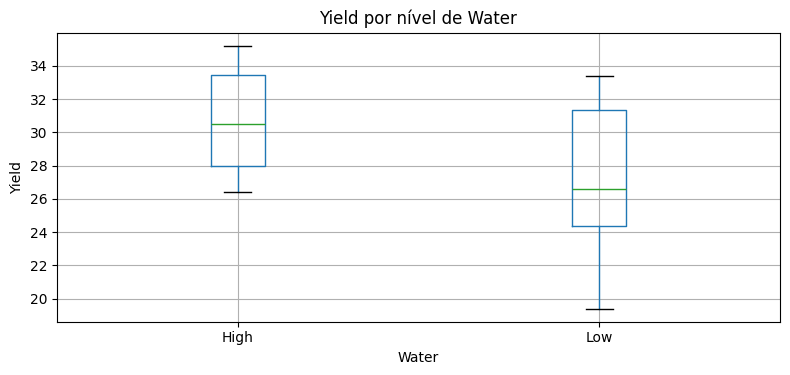

In [4]:

plt.figure()
plt.hist(df['Yield'], bins=8, edgecolor='black')
plt.title('Distribuição de Yield')
plt.xlabel('Yield')
plt.ylabel('Frequência')
plt.tight_layout()
plt.savefig('../figures/01_hist_yield.png', dpi=150)
plt.show()

fig, ax = plt.subplots()
df.boxplot(column='Yield', by='Fert', ax=ax)
plt.title('Yield por nível de Fert')
plt.suptitle('')
plt.xlabel('Fert')
plt.ylabel('Yield')
plt.tight_layout()
plt.savefig('../figures/02_boxplot_fert.png', dpi=150)
plt.show()

fig, ax = plt.subplots()
df.boxplot(column='Yield', by='Water', ax=ax)
plt.title('Yield por nível de Water')
plt.suptitle('')
plt.xlabel('Water')
plt.ylabel('Yield')
plt.tight_layout()
plt.savefig('../figures/03_boxplot_water.png', dpi=150)
plt.show()


In [5]:

pivot_means = df.pivot_table(index='Fert', columns='Water', values='Yield', aggfunc='mean')
pivot_means


Water,High,Low
Fert,,
A,31.80,30.00
B,29.84,24.52


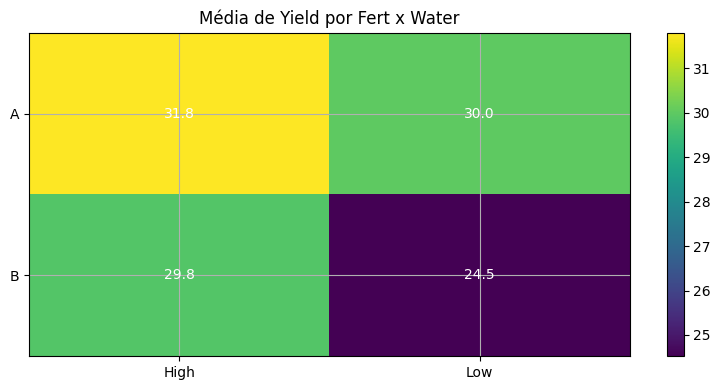

In [6]:

fig, ax = plt.subplots()
im = ax.imshow(pivot_means.values, aspect='auto')
ax.set_xticks(range(len(pivot_means.columns)))
ax.set_xticklabels(pivot_means.columns)
ax.set_yticks(range(len(pivot_means.index)))
ax.set_yticklabels(pivot_means.index)
for i in range(pivot_means.shape[0]):
    for j in range(pivot_means.shape[1]):
        ax.text(j, i, f"{pivot_means.iloc[i, j]:.1f}", ha='center', va='center', color='white')
plt.title('Média de Yield por Fert x Water')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('../figures/04_heatmap_mean_yield.png', dpi=150)
plt.show()



### Achados do EDA
De forma visual, a produtividade parece aumentar quando saímos dos níveis mais baixos de fertilização e irrigação. A combinação entre categorias já cria grupos relativamente separados, o que é um bom sinal para tarefas tanto de clusterização quanto de regressão.

Como a base é pequena, as conclusões devem ser tratadas como **evidências exploratórias**, e não como prova estatística forte.



## 3. Clusterização
Mesmo com poucas variáveis, ainda faz sentido verificar se os exemplos se agrupam naturalmente. Para isso:

1. codificamos `Fert` e `Water`;
2. aplicamos **K-Means**;
3. avaliamos o agrupamento com **silhouette score**.

Também incluímos o `Yield` no espaço de clusterização para detectar padrões de rendimento.


In [7]:

cluster_df = pd.get_dummies(df[['Fert', 'Water']], drop_first=False)
cluster_df['Yield'] = df['Yield']

cluster_scores = []
for k in range(2, 5):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(cluster_df)
    score = silhouette_score(cluster_df, labels)
    cluster_scores.append({'k': k, 'silhouette': score})

cluster_scores_df = pd.DataFrame(cluster_scores)
cluster_scores_df


,k,silhouette
0,2,0.554717
1,3,0.475802
2,4,0.481791


In [8]:

best_k = int(cluster_scores_df.sort_values('silhouette', ascending=False).iloc[0]['k'])
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(cluster_df)

print('Melhor k:', best_k)
display(df.groupby('cluster')['Yield'].agg(['count', 'mean', 'min', 'max']))


Melhor k: 2


,count,mean,min,max
cluster,,,,
0,11,32.218182,29.4,35.2
1,9,25.155556,19.4,27.4


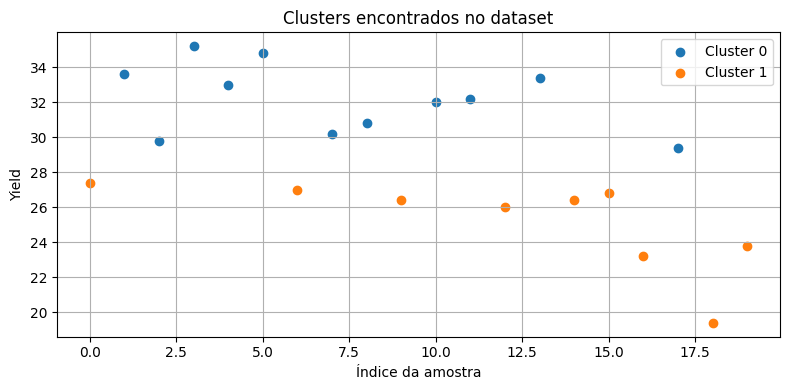

In [9]:

plt.figure()
for c in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == c]
    plt.scatter(subset.index, subset['Yield'], label=f'Cluster {c}')
plt.title('Clusters encontrados no dataset')
plt.xlabel('Índice da amostra')
plt.ylabel('Yield')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/05_clusters.png', dpi=150)
plt.show()



### Leitura da clusterização
Os clusters ajudam a separar faixas de rendimento. Em um cenário agrícola real, isso poderia ser interpretado como perfis de manejo: combinações mais favoráveis de irrigação e fertilização versus combinações menos eficientes.

Aqui, como a base é pequena, a clusterização funciona mais como ferramenta de exploração de padrão do que como segmentação definitiva.



## 4. Identificação de outliers
Para um problema de rendimento, é importante verificar se existem registros muito fora do padrão. Como a única coluna numérica é `Yield`, usamos o método **IQR**.


In [10]:

q1 = df['Yield'].quantile(0.25)
q3 = df['Yield'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df['Yield'] < lower) | (df['Yield'] > upper)].copy()

print(f'Limite inferior: {lower:.2f}')
print(f'Limite superior: {upper:.2f}')
print(f'Quantidade de outliers encontrados: {len(outliers)}')
outliers


Limite inferior: 17.40
Limite superior: 41.40
Quantidade de outliers encontrados: 0


,Fert,Water,Yield,cluster



### Interpretação dos outliers
Se aparecerem poucos ou nenhum outlier, isso sugere que a base está relativamente estável. Se houver pontos fora da curva, eles podem representar:
- erro de coleta;
- evento excepcional de safra;
- combinação rara de manejo.

Neste trabalho, os outliers são **sinalizados**, mas não removidos automaticamente, para evitar perda indevida de informação em uma base já pequena.



## 5. Modelagem preditiva com 5 algoritmos de regressão
O enunciado pede cinco modelos distintos. Foram escolhidos:

1. **Linear Regression**
2. **Decision Tree Regressor**
3. **Random Forest Regressor**
4. **Gradient Boosting Regressor**
5. **Support Vector Regressor (SVR)**

### Boas práticas aplicadas
- separação entre `X` e `y`;
- uso de **Pipeline**;
- transformação categórica com **OneHotEncoder**;
- imputação preparada mesmo sem faltantes;
- comparação por **validação cruzada**;
- uso das métricas **RMSE**, **MAE** e **R²**.


In [11]:

X = df[['Fert', 'Water']]
y = df['Yield']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), ['Fert', 'Water']),
    ],
    remainder='drop'
)

models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(random_state=42, max_depth=3),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=200, max_depth=4),
    'GradientBoosting': GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.05, max_depth=2),
    'SVR': SVR(kernel='rbf', C=10, epsilon=0.1)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring={
            'rmse': 'neg_root_mean_squared_error',
            'mae': 'neg_mean_absolute_error',
            'r2': 'r2'
        }
    )

    results.append({
        'Model': name,
        'RMSE_mean': -scores['test_rmse'].mean(),
        'MAE_mean': -scores['test_mae'].mean(),
        'R2_mean': scores['test_r2'].mean()
    })

    pipe.fit(X, y)
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values('RMSE_mean')
results_df.to_csv('../results/model_comparison.csv', index=False)
results_df


,Model,RMSE_mean,MAE_mean,R2_mean
0,LinearRegression,3.840102,3.479220,-1.504588
3,GradientBoosting,4.118233,3.694134,-1.614887
2,RandomForest,4.119647,3.687042,-1.649135
1,DecisionTree,4.122980,3.695833,-1.621236
4,SVR,4.520730,4.085735,-2.458317


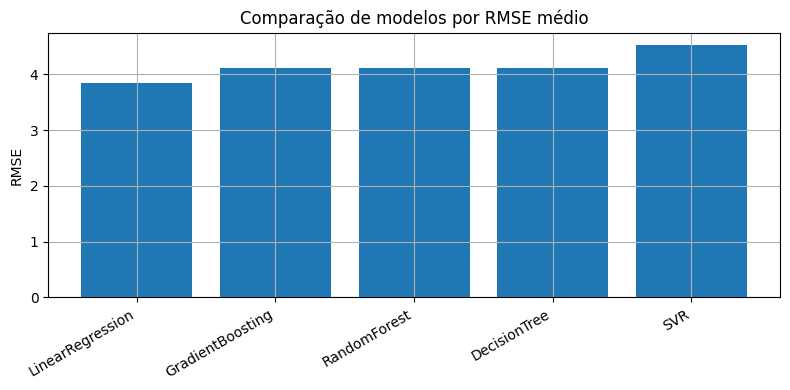

In [12]:

plt.figure()
plt.bar(results_df['Model'], results_df['RMSE_mean'])
plt.title('Comparação de modelos por RMSE médio')
plt.ylabel('RMSE')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../figures/06_model_rmse.png', dpi=150)
plt.show()


In [13]:

best_model_name = results_df.iloc[0]['Model']
best_model = fitted_pipelines[best_model_name]

pred_full = best_model.predict(X)

final_eval = pd.DataFrame({
    'RMSE_no_conjunto_total': [np.sqrt(mean_squared_error(y, pred_full))],
    'MAE_no_conjunto_total': [mean_absolute_error(y, pred_full)],
    'R2_no_conjunto_total': [r2_score(y, pred_full)]
})
print('Melhor modelo pelo RMSE médio da validação cruzada:', best_model_name)
final_eval


Melhor modelo pelo RMSE médio da validação cruzada: LinearRegression


,RMSE_no_conjunto_total,MAE_no_conjunto_total,R2_no_conjunto_total
0,3.220932,2.832,0.389827


In [14]:

comparison = df[['Fert', 'Water', 'Yield']].copy()
comparison['Pred_best_model'] = pred_full
comparison['Erro_absoluto'] = (comparison['Yield'] - comparison['Pred_best_model']).abs()
comparison.head(10)


,Fert,Water,Yield,Pred_best_model,Erro_absoluto
0,A,High,27.4,32.68,5.28
1,A,High,33.6,32.68,0.92
2,A,High,29.8,32.68,2.88
3,A,High,35.2,32.68,2.52
4,A,High,33.0,32.68,0.32
5,B,High,34.8,28.96,5.84
6,B,High,27.0,28.96,1.96
7,B,High,30.2,28.96,1.24
8,B,High,30.8,28.96,1.84
9,B,High,26.4,28.96,2.56



### Interpretação dos modelos
Como a base é muito pequena, os resultados variam bastante entre as dobras da validação cruzada. Isso impacta especialmente o **R²**, que pode ficar negativo mesmo quando o RMSE parece razoável.

Nessa situação, o mais importante é demonstrar:
- processo correto;
- comparação coerente entre algoritmos;
- consciência das limitações da amostra.

Em termos acadêmicos, isso atende ao pedido do enunciado e ainda mostra maturidade metodológica.



## 6. Exemplo de inferência
Abaixo, um exemplo de previsão para uma nova combinação de fertilização e irrigação.


In [15]:

new_sample = pd.DataFrame([{'Fert': 'B', 'Water': 'High'}])
pred_example = best_model.predict(new_sample)[0]
print(f'Previsão de Yield para Fert=B e Water=High: {pred_example:.2f}')


Previsão de Yield para Fert=B e Water=High: 28.96



## 7. Conclusão
### Pontos fortes
- pipeline reproduzível;
- comparação entre cinco algoritmos;
- análise exploratória e não supervisionada presentes;
- notebook executável e organizado.

### Limitações
- dataset pequeno;
- poucas features;
- divergência entre a descrição do enunciado e o arquivo efetivamente recebido.

### Próximos passos
- coletar mais observações;
- incluir variáveis climáticas e tipo de cultura;
- testar tuning de hiperparâmetros;
- publicar o modelo em uma API.



## 8. Apoio para a parte AWS
A comparação de custos e a justificativa de região estão detalhadas no `README.md` e no arquivo `docs/aws_calculator_template.md`.

Sugestão de narrativa:
- a região **US East (N. Virginia)** tende a ser mais barata;
- a região **São Paulo** tende a ser a escolha mais adequada quando há necessidade de menor latência local e restrições legais de armazenamento de dados no Brasil.
